In [7]:
!pip install qiskit
!pip install qiskit matplotlib pylatexenc
!pip install jupyter
!pip install sympy
!pip install matplotlib
from qiskit.quantum_info import Statevector
from numpy import sqrt
from qiskit.visualization import plot_histogram
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
!pip install qiskit-aer
from qiskit_aer import AerSimulator



ModuleNotFoundError: No module named 'qiskit_aer'

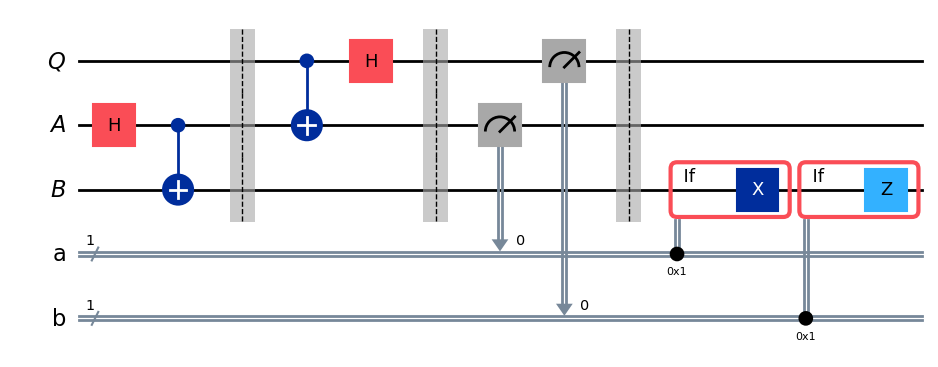

In [2]:
qubit = QuantumRegister(1, "Q")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")
a = ClassicalRegister(1, "a")
b = ClassicalRegister(1, "b")

protocol = QuantumCircuit(qubit, ebit0, ebit1, a, b)

# Prepare ebit used for teleportation
protocol.h(ebit0)
protocol.cx(ebit0, ebit1)
protocol.barrier()

# Alice's operations
protocol.cx(qubit, ebit0)
protocol.h(qubit)
protocol.barrier()

# Alice measures and sends classical bits to Bob
protocol.measure(ebit0, a)
protocol.measure(qubit, b)
protocol.barrier()

# Bob uses the classical bits to conditionally apply gates
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)

display(protocol.draw(output="mpl"))

In [4]:
#created a random gate
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, array_to_latex
from qiskit.result import marginal_distribution
from qiskit.circuit.library import UGate
from math import pi
import random
random_gate = UGate(
    theta=random.random() * 2 * pi,
    phi=random.random() * 2 * pi,
    lam=random.random() * 2 * pi,
)

display(array_to_latex(random_gate.to_matrix()))

<IPython.core.display.Latex object>

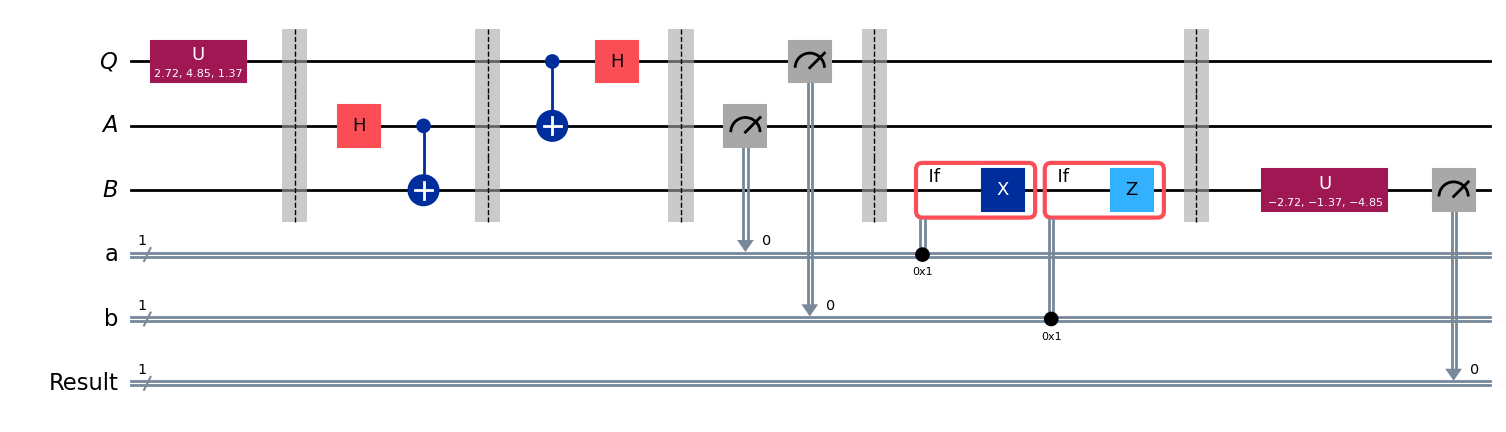

In [5]:
#Testing teleportation using that random gate we created
test=QuantumCircuit(qubit,ebit0,ebit1,a,b)

test.append(random_gate,qubit)
test.barrier()

test=test.compose(protocol)
test.barrier()

test.append(random_gate.inverse(),ebit1)
result=ClassicalRegister(1,"Result")
test.add_register(result)
test.measure(ebit1,result)

display(test.draw(output="mpl"))

In [8]:
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 57.5 MB/s eta 0:00:00


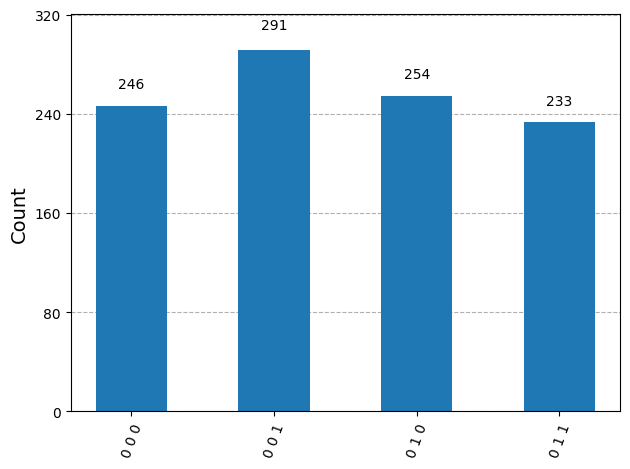

In [9]:
#let's run the Aer simulator on this circuit and plot a histogram of the outputs
from qiskit_aer import AerSimulator
result=AerSimulator().run(test).result()
statistics=result.get_counts()
display(plot_histogram(statistics))

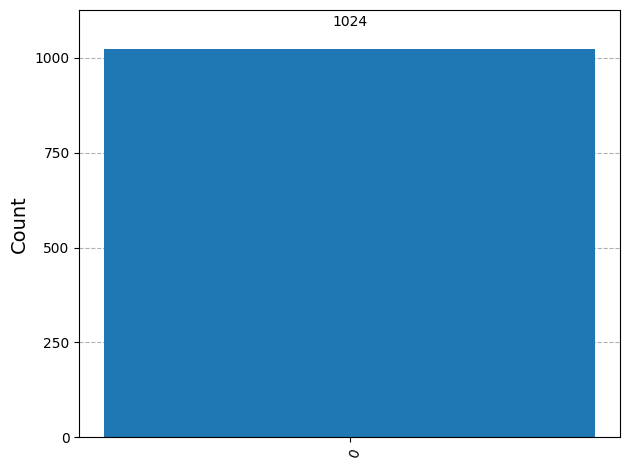

In [10]:
#This code is just filtering the measurement results so you can look at only the final test qubit (Bob's qubit) instead of all the measured bits.
filtered_statistics=marginal_distribution(statistics,[2])
display(plot_histogram(filtered_statistics))

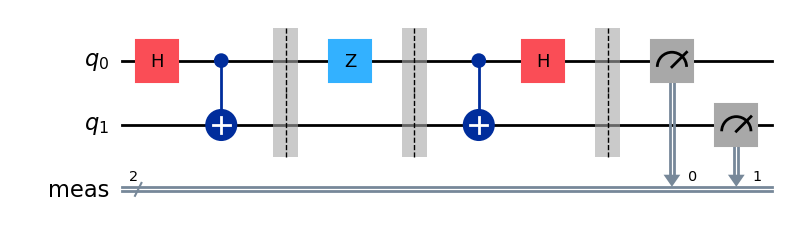

Measured 01 with frequency 1024 : 


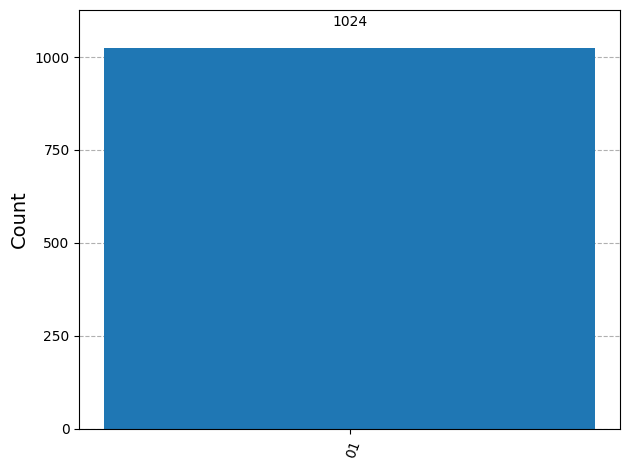

In [11]:
#Superdense Coding
c="0"
d="1"
protoco1=QuantumCircuit(2)
protoco1.h(0)
protoco1.cx(0,1)
protoco1.barrier()

if d=="1":
  protoco1.z(0)
if c=="1":
  protoco1.x(0)
protoco1.barrier()

protoco1.cx(0,1)
protoco1.h(0)
protoco1.measure_all()

display(protoco1.draw(output="mpl"))

#Running the Aer simulator produces the expected output
result=AerSimulator().run(protoco1).result()
statistics = result.get_counts()

for outcome, frequency in statistics.items():
  print(f"Measured {outcome} with frequency {frequency} : ")

display(plot_histogram(statistics))

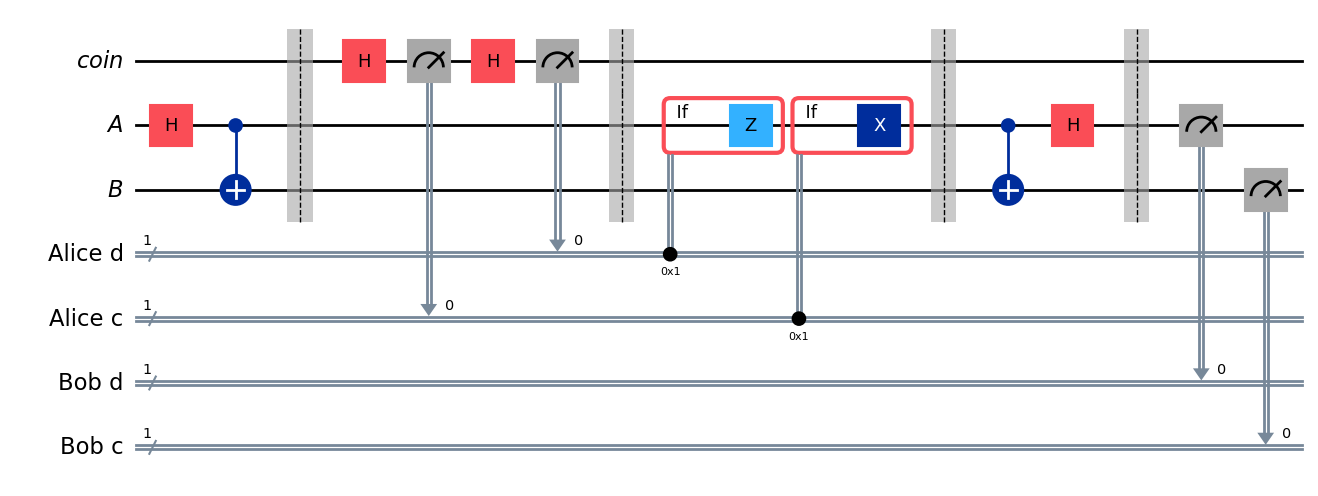

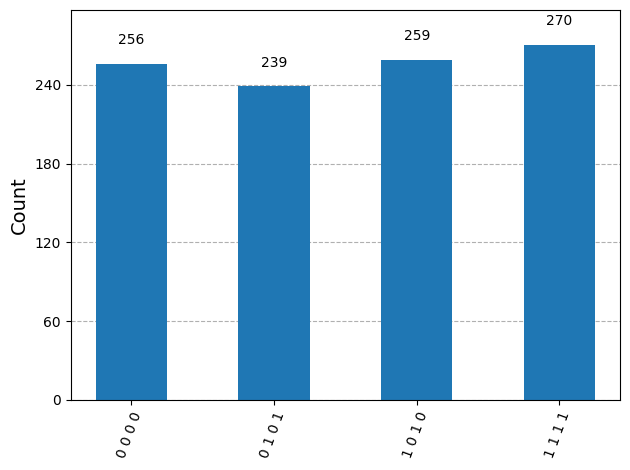

In [12]:
# Let's use an additional qubit as a random bit generator
rbg = QuantumRegister(1, "coin")
ebit0 = QuantumRegister(1, "A")
ebit1 = QuantumRegister(1, "B")

Alice_c = ClassicalRegister(1, "Alice c")
Alice_d = ClassicalRegister(1, "Alice d")

test = QuantumCircuit(rbg, ebit0, ebit1, Alice_d, Alice_c)

# Initialize the ebit
test.h(ebit0)
test.cx(ebit0, ebit1)
test.barrier()

# Use the 'coin' qubit twice to generate Alice's bits c and d.
test.h(rbg)
test.measure(rbg, Alice_c)
test.h(rbg)
test.measure(rbg, Alice_d)
test.barrier()

# Now the protocol runs, starting with Alice's actions, which depend
# on her bits.
with test.if_test((Alice_d, 1), label="Z"):
    test.z(ebit0)
with test.if_test((Alice_c, 1), label="X"):
    test.x(ebit0)
test.barrier()

# Bob's actions
test.cx(ebit0, ebit1)
test.h(ebit0)
test.barrier()

Bob_c = ClassicalRegister(1, "Bob c")
Bob_d = ClassicalRegister(1, "Bob d")
test.add_register(Bob_d)
test.add_register(Bob_c)
test.measure(ebit0, Bob_d)
test.measure(ebit1, Bob_c)

display(test.draw(output="mpl"))


result = AerSimulator().run(test).result()
statistics = result.get_counts()
display(plot_histogram(statistics))

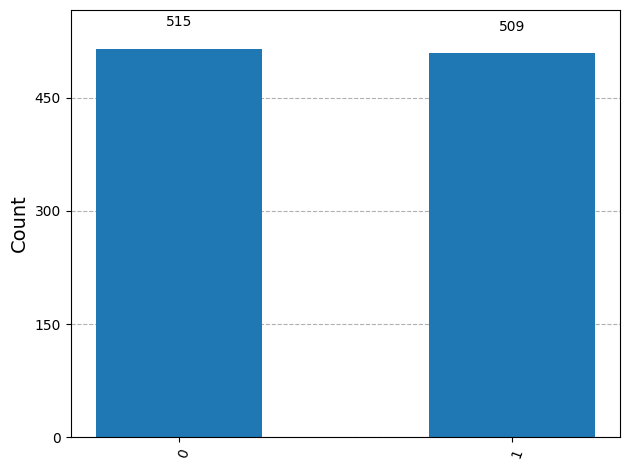

In [13]:
filtered_statistics=marginal_distribution(statistics,[2])
display(plot_histogram(filtered_statistics))